In [ ]:
# instalar si es necesario:    pip install yfinance pandas numpy matplotlib

### Descarga inicial de datos

En esta celda se descargan los precios históricos diarios del activo seleccionado, en este caso `SPY`, usando la librería `yfinance`.

La tabla obtenida se guarda en la variable `raw` y contiene la información básica de mercado para cada fecha: precio de apertura, máximo, mínimo, cierre, cierre ajustado y volumen operado.

El comando `raw.head()` muestra las primeras filas de la base de datos. Esto permite verificar que la descarga se realizó correctamente, revisar las columnas disponibles y confirmar que la serie empieza en la fecha esperada.

En las siguientes etapas se usará principalmente la columna de precio de cierre ajustado (`Adj Close`), porque permite calcular rendimientos logarítmicos de forma más consistente.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "SPY"

raw = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=False,
    progress=False
)

raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2015-01-02,169.687851,205.429993,206.880005,204.179993,206.380005,121465900
2015-01-05,166.623337,201.720001,204.369995,201.350006,204.169998,169632600
2015-01-06,165.053925,199.820007,202.720001,198.860001,202.089996,209151400
2015-01-07,167.110703,202.309998,202.720001,200.880005,201.419998,125346700
2015-01-08,170.076096,205.899994,206.160004,203.990005,204.009995,147217800


In [2]:
raw.shape

(2766, 6)

In [3]:
raw.columns

MultiIndex([('Adj Close', 'SPY'),
            (    'Close', 'SPY'),
            (     'High', 'SPY'),
            (      'Low', 'SPY'),
            (     'Open', 'SPY'),
            (   'Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [4]:
raw.index.min(), raw.index.max()

(Timestamp('2015-01-02 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [5]:
raw.isna().sum()

Price      Ticker
Adj Close  SPY       0
Close      SPY       0
High       SPY       0
Low        SPY       0
Open       SPY       0
Volume     SPY       0
dtype: int64

### Selección del precio ajustado

En la siguiente celda seleccionamos la columna `Adj Close`, que corresponde al precio de cierre ajustado.

Este precio será la base para calcular los rendimientos logarítmicos, ya que incorpora ajustes por eventos corporativos como dividendos o divisiones de acciones.

In [6]:
prices = raw["Adj Close"].copy()

prices.head()

Ticker,SPY
Date,
2015-01-02,169.687851
2015-01-05,166.623337
2015-01-06,165.053925
2015-01-07,167.110703
2015-01-08,170.076096


### Gráfica del precio ajustado

La siguiente gráfica muestra la evolución temporal del precio ajustado del activo seleccionado.

El objetivo no es predecir directamente esta serie de precios, sino observar su comportamiento general antes de transformarla en rendimientos.

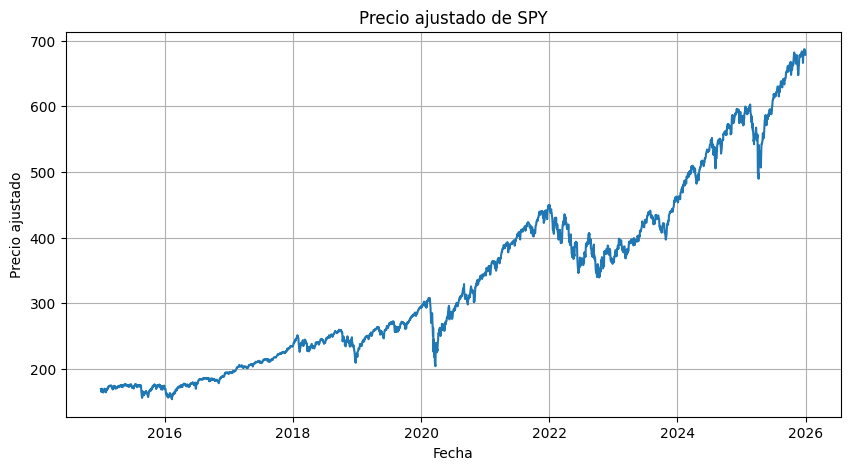

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(prices)
plt.title("Precio ajustado de SPY")
plt.xlabel("Fecha")
plt.ylabel("Precio ajustado")
plt.grid(True)
plt.show()

### Rendimientos logarítmicos

En la siguiente  celda calculamos los rendimientos logarítmicos diarios a partir del precio ajustado.

La fórmula utilizada es

$$
r_t = \log(P_t) - \log(P_{t-1}).
$$

Los rendimientos logarítmicos permiten estudiar cambios relativos del precio y son más adecuados que los precios para analizar volatilidad.

In [8]:
log_returns = np.log(prices / prices.shift(1)).dropna()

log_returns.head()

Ticker,SPY
Date,
2015-01-05,-0.018225
2015-01-06,-0.009464
2015-01-07,0.012384
2015-01-08,0.017589
2015-01-09,-0.008046


### Gráfica de rendimientos logarítmicos

Esta gráfica muestra los rendimientos logarítmicos diarios del activo.

A diferencia de los precios, los rendimientos suelen fluctuar alrededor de cero. Además, se pueden observar periodos con mayor variabilidad, lo cual está relacionado con la volatilidad financiera.

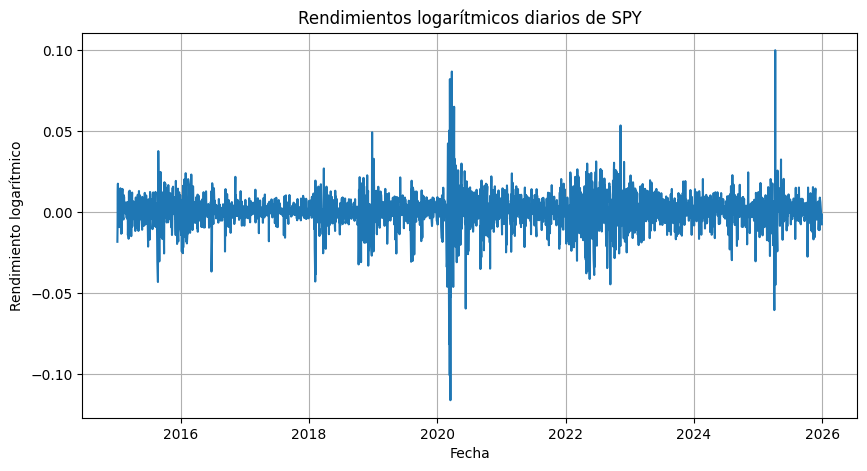

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(log_returns)
plt.title("Rendimientos logarítmicos diarios de SPY")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento logarítmico")
plt.grid(True)
plt.show()

## Ejercicios en Python

A partir de esta sección, realiza los siguientes ejercicios usando la base descargada y los rendimientos logarítmicos calculados previamente.

La variable principal de trabajo será `log_returns`, que contiene los rendimientos logarítmicos diarios del activo seleccionado.

---

### Ejercicio 1. Estadística descriptiva básica

Calcula las siguientes estadísticas para los rendimientos logarítmicos:

1. media;
2. desviación estándar;
3. valor mínimo;
4. valor máximo;
5. mediana.

Guarda los resultados en una tabla de `pandas`.

**Pregunta:** ¿La media de los rendimientos está cerca de cero?

---

### Ejercicio 2. Interpretación de la desviación estándar

Calcula la desviación estándar diaria de los rendimientos logarítmicos.

Después anualiza la volatilidad usando la fórmula

$$
\sigma_{\text{anual}} = \sigma_{\text{diaria}}\sqrt{252}.
$$

**Pregunta:** ¿Cuál es la volatilidad anualizada aproximada del activo?

---

### Ejercicio 3. Días con mayor caída

Ordena los rendimientos logarítmicos de menor a mayor y muestra los 10 días con rendimientos más negativos.

**Pregunta:** ¿En qué fechas ocurrieron las mayores caídas del activo?

---

### Ejercicio 4. Días con mayor subida

Ordena los rendimientos logarítmicos de mayor a menor y muestra los 10 días con rendimientos más positivos.

**Pregunta:** ¿En qué fechas ocurrieron las mayores subidas del activo?

---

### Ejercicio 5. Histograma de rendimientos

Construye un histograma de los rendimientos logarítmicos diarios.

Usa un número razonable de barras, por ejemplo `bins=50`.

**Pregunta:** ¿La mayoría de los rendimientos se concentra cerca de cero?

---

### Ejercicio 6. Comparación entre precio y rendimientos

Grafica en una figura el precio ajustado del activo.

Después, en otra figura, grafica los rendimientos logarítmicos.

**Pregunta:** ¿Cuál de las dos series parece más adecuada para estudiar volatilidad: precios o rendimientos?
